In [1]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from statannotations.Annotator import Annotator

In [2]:
sge_set=pd.read_excel('./Data/sge_data_for_qc/spliceai_benchmarking/20260512_SGESplicingSet.xlsx')
curated_set=pd.read_excel('./Data/sge_data_for_qc/spliceai_benchmarking/20260512_CuratedSplicingSet.xlsx')
clinvar_set = pd.read_excel('./Data/sge_data_for_qc/spliceai_benchmarking/20260512_ClinVarSplicingSet.xlsx')

# Sensitivity and specificity across the datasets

In [3]:
# Maps SGE simplified_consequence labels → curated/ClinVar VEP SO term labels
CONSEQUENCE_MAP = {
    'Intron':           ['intron_variant'],
    'Splice Region':    ['splice_donor_region_variant', 'splice_polypyrimidine_tract_variant',
                         'splice_donor_5th_base_variant', 'splice_region_variant'],
    'Canonical Splice': ['splice_acceptor_variant', 'splice_donor_variant'],
    'Missense':         ['missense_variant'],
    'Synonymous':       ['synonymous_variant'],
}

SGE_LABEL_COL    = 'auth_reported_func_class'
SGE_POS_LABEL    = 'functionally_abnormal'
SGE_NEG_LABEL    = 'functionally_normal'

CURATED_LABEL_COL = 'splice_consequence'
CURATED_POS_LABEL = 'abnormal'
CURATED_NEG_LABEL = 'normal'

CLINVAR_LABEL_COL = 'ClinicalSignificance'
CLINVAR_POS_LABEL = 'PLP'
CLINVAR_NEG_LABEL = 'BLB'
CLINVAR_CONS_COL  = 'first_consequence'


def build_confusion_matrix(df, label_col, pos_label, neg_label,
                            score_col='maxSpliceAI', threshold=0.2):
    """Returns [[TN, FP], [FN, TP]] at a fixed threshold."""
    sub = df[df[label_col].isin([pos_label, neg_label])].dropna(subset=[score_col])
    pos = sub[sub[label_col] == pos_label]
    neg = sub[sub[label_col] == neg_label]
    tp = int((pos[score_col] >= threshold).sum())
    fn = int((pos[score_col] <  threshold).sum())
    tn = int((neg[score_col] <  threshold).sum())
    fp = int((neg[score_col] >= threshold).sum())
    return np.array([[tn, fp], [fn, tp]])


def compare_components(cms, labels, bonferroni_factor=None):
    """
    Compare sensitivity and specificity across N datasets.
    cms:              list of [[TN, FP], [FN, TP]] confusion matrices
    labels:           list of dataset names, same length as cms
    bonferroni_factor: if None (default), correction = n_eligible_pairs (per metric).
                      Pass a fixed value (e.g. 3 for 3 datasets) to keep
                      p-values comparable across rows with different eligibility.

    Returns a dict keyed by metric with per-dataset values, n counts,
    and corrected p-values for every eligible pair as 'p_{A}_vs_{B}'.
    """
    n_pairs = len(cms) * (len(cms) - 1) // 2
    factor  = bonferroni_factor if bonferroni_factor is not None else n_pairs

    metric_counts = {
        'sensitivity': lambda cm: (cm[1, 1], cm[1, 0]),  # TP, FN
        'specificity': lambda cm: (cm[0, 0], cm[0, 1]),  # TN, FP
    }

    results = {}
    for metric, get_counts in metric_counts.items():
        entry = {}
        for label, cm in zip(labels, cms):
            s, f = get_counts(cm)
            entry[label] = s / (s + f)
            entry[f'n_{label}'] = int(s + f)

        for la, lb in itertools.combinations(labels, 2):
            s_a, f_a = get_counts(cms[labels.index(la)])
            s_b, f_b = get_counts(cms[labels.index(lb)])
            _, p = proportions_ztest([s_a, s_b], [s_a + f_a, s_b + f_b])
            entry[f'p_{la}_vs_{lb}'] = min(p * factor, 1.0)

        results[metric] = entry

    return results

In [4]:
RNA_FILTERABLE = {'Splice Region', 'Missense', 'Synonymous'}
ALL_DATASET_LABELS = ['SGE', 'Curated', 'ClinVar']

def get_sge_sub(sge_set, group_name, rna_filtered=False):
    sub = sge_set[sge_set['simplified_consequence'] == group_name]
    if rna_filtered:
        # Positives: functionally_abnormal with rna_consequence == 'low'
        # Negatives: functionally_normal with rna_consequence == 'normal'
        sub = sub[
            ((sub[SGE_LABEL_COL] == SGE_NEG_LABEL) & (sub['rna_consequence'] == 'normal')) |
            ((sub[SGE_LABEL_COL] == SGE_POS_LABEL) & (sub['rna_consequence'] == 'low'))
        ]
    return sub


rows = []
for group_name, curated_consequences in CONSEQUENCE_MAP.items():
    cur_sub = curated_set[curated_set['simplified_consequence'].isin(curated_consequences)]
    clv_sub = clinvar_set[clinvar_set[CLINVAR_CONS_COL].isin(curated_consequences)]

    variants = [(group_name, False)]
    if group_name in RNA_FILTERABLE:
        variants.append((f'{group_name} (Low RNA)', True))

    for label, rna_filtered in variants:
        sge_sub = get_sge_sub(sge_set, group_name, rna_filtered)

        dataset_specs = [
            ('SGE',     sge_sub, SGE_LABEL_COL,     SGE_POS_LABEL,     SGE_NEG_LABEL),
            ('Curated', cur_sub, CURATED_LABEL_COL, CURATED_POS_LABEL, CURATED_NEG_LABEL),
            ('ClinVar', clv_sub, CLINVAR_LABEL_COL, CLINVAR_POS_LABEL, CLINVAR_NEG_LABEL),
        ]

        cms_map = {}
        count_info = []
        for ds_label, sub_df, label_col, pos_label, neg_label in dataset_specs:
            n_pos = sub_df[label_col].eq(pos_label).sum()
            n_neg = sub_df[label_col].eq(neg_label).sum()
            count_info.append(f'{ds_label} +{n_pos}/-{n_neg}')
            if min(n_pos, n_neg) >= 5:
                cms_map[ds_label] = build_confusion_matrix(sub_df, label_col, pos_label, neg_label)
            else:
                cms_map[ds_label] = None

        eligible = [k for k, v in cms_map.items() if v is not None]
        if not eligible:
            print(f'Skipping {label}: insufficient counts for all datasets ({", ".join(count_info)})')
            continue

        insufficient = [k for k, v in cms_map.items() if v is None]
        if insufficient:
            print(f'{label}: {insufficient} excluded (insufficient counts), using {eligible} only')

        result = compare_components(
            [cms_map[k] for k in eligible],
            eligible
        )

        for metric, vals in result.items():
            row = {'consequence': label, 'metric': metric}
            for ds_label in ALL_DATASET_LABELS:
                row[ds_label]        = vals.get(ds_label, np.nan)
                row[f'n_{ds_label}'] = vals.get(f'n_{ds_label}', np.nan)
            for la, lb in itertools.combinations(ALL_DATASET_LABELS, 2):
                row[f'p_{la}_vs_{lb}'] = vals.get(f'p_{la}_vs_{lb}', np.nan)
            rows.append(row)

comparison_df = pd.DataFrame(rows)

fmt = lambda x: f'{x:.3f}'
sensitivity_df = comparison_df[comparison_df['metric'] == 'sensitivity'].drop(columns='metric').reset_index(drop=True)
specificity_df = comparison_df[comparison_df['metric'] == 'specificity'].drop(columns='metric').reset_index(drop=True)

print('=== Sensitivity ===')
print(sensitivity_df.to_string(index=False, float_format=fmt))
print()
print('=== Specificity ===')
print(specificity_df.to_string(index=False, float_format=fmt))

Intron: ['Curated'] excluded (insufficient counts), using ['SGE', 'ClinVar'] only
Canonical Splice: ['Curated'] excluded (insufficient counts), using ['SGE', 'ClinVar'] only
Missense: ['ClinVar'] excluded (insufficient counts), using ['SGE', 'Curated'] only
Missense (Low RNA): ['ClinVar'] excluded (insufficient counts), using ['SGE', 'Curated'] only
=== Sensitivity ===
            consequence   SGE  n_SGE  Curated  n_Curated  ClinVar  n_ClinVar  p_SGE_vs_Curated  p_SGE_vs_ClinVar  p_Curated_vs_ClinVar
                 Intron 0.319    342      NaN        NaN    0.586     29.000               NaN             0.003                   NaN
          Splice Region 0.747    747    0.873     71.000    0.917    337.000             0.053             0.000                 0.732
Splice Region (Low RNA) 0.840     25    0.873     71.000    0.917    337.000             1.000             0.574                 0.732
       Canonical Splice 0.995   1033      NaN        NaN    0.995   2914.000            

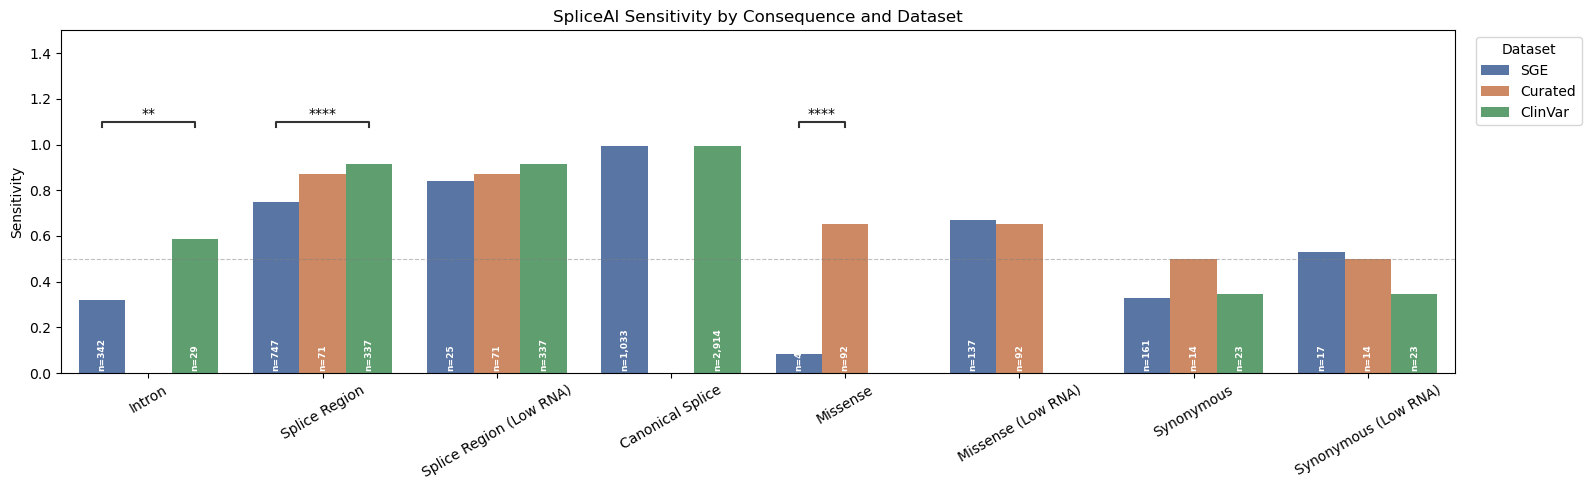

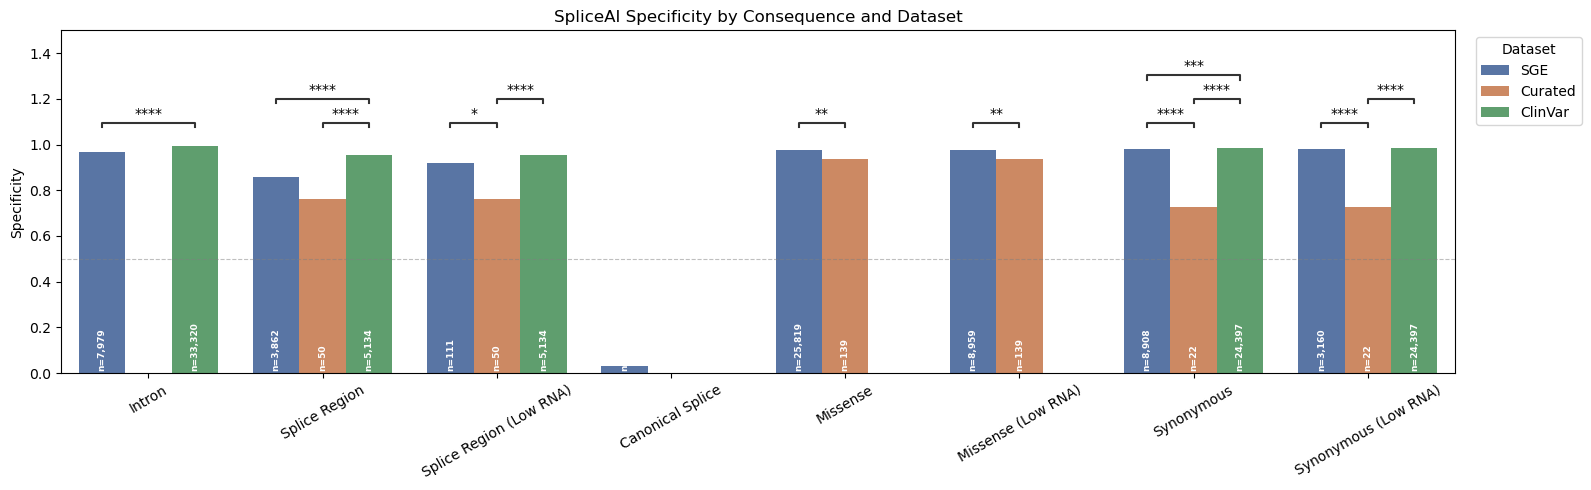

In [5]:
DATASET_COLORS = {'SGE': '#4C72B0', 'Curated': '#DD8452', 'ClinVar': '#55A868'}
DATASET_ORDER  = ['SGE', 'Curated', 'ClinVar']

P_COL_MAP = {
    ('SGE',     'Curated'):  'p_SGE_vs_Curated',
    ('SGE',     'ClinVar'):  'p_SGE_vs_ClinVar',
    ('Curated', 'ClinVar'):  'p_Curated_vs_ClinVar',
}


def plot_metric(metric_df, metric_name):
    cons_order = metric_df['consequence'].tolist()

    # Long-format: only rows for datasets with non-NaN values
    long_rows = []
    for _, row in metric_df.iterrows():
        for ds in DATASET_ORDER:
            if not pd.isna(row[ds]):
                long_rows.append({
                    'consequence': row['consequence'],
                    'dataset':     ds,
                    'value':       row[ds],
                    'n':           int(row[f'n_{ds}']),
                })
    long_df = pd.DataFrame(long_rows)

    fig, ax = plt.subplots(figsize=(max(8, len(cons_order) * 2), 5))

    sns.barplot(
        data=long_df, x='consequence', y='value', hue='dataset',
        palette=DATASET_COLORS, hue_order=DATASET_ORDER,
        order=cons_order, ax=ax,
    )

    # Add n labels on bars
    n_hue     = len(DATASET_ORDER)
    bar_width = 0.8 / n_hue
    for i, cons in enumerate(cons_order):
        for j, ds in enumerate(DATASET_ORDER):
            subset = long_df[(long_df['consequence'] == cons) & (long_df['dataset'] == ds)]
            if subset.empty:
                continue
            n_val  = subset['n'].iloc[0]
            x_pos  = i + (j - (n_hue - 1) / 2) * bar_width
            ax.text(x_pos, 0.01, f'n={n_val:,}',
                    ha='center', va='bottom', fontsize=6.5,
                    color='white', fontweight='bold', rotation=90)

    # Collect significant pairs for annotation
    sig_pairs, sig_pvals = [], []
    for _, row in metric_df.iterrows():
        cons = row['consequence']
        for (ds_a, ds_b), p_col in P_COL_MAP.items():
            p = row.get(p_col, np.nan)
            if not pd.isna(p) and p < 0.05:
                sig_pairs.append(((cons, ds_a), (cons, ds_b)))
                sig_pvals.append(p)

    if sig_pairs:
        annotator = Annotator(
            ax, sig_pairs, data=long_df,
            x='consequence', y='value', hue='dataset',
            order=cons_order, hue_order=DATASET_ORDER,
        )
        annotator.configure(test=None, text_format='star', loc='outside', verbose=False)
        annotator.set_pvalues_and_annotate(sig_pvals)

    ax.set_title(f'SpliceAI {metric_name.capitalize()} by Consequence and Dataset')
    ax.set_xlabel('')
    ax.set_ylabel(metric_name.capitalize())
    ax.set_ylim(0, 1.5)
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Dataset', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    return fig


fig_sens = plot_metric(sensitivity_df, 'sensitivity')
fig_spec = plot_metric(specificity_df, 'specificity')
plt.show()

# Sensitivity and specificity of SpliceAI predictions before and after RNA filtering

In [6]:
# Within-SGE: unfiltered labels vs RNA-confirmed labels
# P-values: Fisher's exact test on RNA-confirmed vs excluded (non-RNA-confirmed)
# disjoint subgroups. Classic McNemar's doesn't apply here because the population
# changes between conditions (sge_rna ⊂ sge_all) rather than the classifier —
# the same SpliceAI scores and threshold are used throughout, so the paired
# discordant cells are always 0. Comparing the two disjoint subgroups is the
# valid independent-samples alternative.
#
# Excluded positives: functionally_abnormal with rna_consequence != 'low'
# Excluded negatives: functionally_normal with rna_consequence != 'normal'

BONFERRONI_RNA = len(RNA_FILTERABLE) * 2  # n_groups × 2 metrics


def _cm_counts(sub_df, label_val, threshold=0.2):
    """Returns (correct_n, incorrect_n) at threshold for the given label class."""
    g = sub_df.loc[sub_df[SGE_LABEL_COL] == label_val, 'maxSpliceAI'].dropna()
    if label_val == SGE_POS_LABEL:
        return int((g >= threshold).sum()), int((g < threshold).sum())  # TP, FN
    return int((g < threshold).sum()), int((g >= threshold).sum())      # TN, FP


rna_rows = []
for group_name in sorted(RNA_FILTERABLE):
    sge_all     = get_sge_sub(sge_set, group_name, rna_filtered=False)
    sge_rna     = get_sge_sub(sge_set, group_name, rna_filtered=True)
    sge_not_rna = sge_all[~sge_all.index.isin(sge_rna.index)]

    counts = {
        'All':           (sge_all[SGE_LABEL_COL].eq(SGE_POS_LABEL).sum(),
                          sge_all[SGE_LABEL_COL].eq(SGE_NEG_LABEL).sum()),
        'RNA-confirmed': (sge_rna[SGE_LABEL_COL].eq(SGE_POS_LABEL).sum(),
                          sge_rna[SGE_LABEL_COL].eq(SGE_NEG_LABEL).sum()),
    }

    if any(min(n_pos, n_neg) < 5 for n_pos, n_neg in counts.values()):
        skipped = [k for k, (p, n) in counts.items() if min(p, n) < 5]
        print(f'Skipping {group_name}: insufficient counts in {skipped} '
              f'({", ".join(f"{k} +{p}/-{n}" for k, (p, n) in counts.items())})')
        continue

    cm_all = build_confusion_matrix(sge_all, SGE_LABEL_COL, SGE_POS_LABEL, SGE_NEG_LABEL)
    cm_rna = build_confusion_matrix(sge_rna, SGE_LABEL_COL, SGE_POS_LABEL, SGE_NEG_LABEL)

    # Fisher's exact: RNA-confirmed vs excluded subgroups (independent, disjoint)
    tp_r, fn_r = _cm_counts(sge_rna,     SGE_POS_LABEL)
    tp_n, fn_n = _cm_counts(sge_not_rna, SGE_POS_LABEL)
    tn_r, fp_r = _cm_counts(sge_rna,     SGE_NEG_LABEL)
    tn_n, fp_n = _cm_counts(sge_not_rna, SGE_NEG_LABEL)

    p_sens_adj = np.nan
    if min(tp_r + fn_r, tp_n + fn_n) >= 5:
        _, p_raw = fisher_exact([[tp_r, fn_r], [tp_n, fn_n]])
        p_sens_adj = min(p_raw * BONFERRONI_RNA, 1.0)

    p_spec_adj = np.nan
    if min(tn_r + fp_r, tn_n + fp_n) >= 5:
        _, p_raw = fisher_exact([[tn_r, fp_r], [tn_n, fp_n]])
        p_spec_adj = min(p_raw * BONFERRONI_RNA, 1.0)

    rna_rows.append({
        'consequence':            group_name,
        'metric':                 'sensitivity',
        'All':                    cm_all[1,1] / (cm_all[1,1] + cm_all[1,0]),
        'RNA-confirmed':          cm_rna[1,1] / (cm_rna[1,1] + cm_rna[1,0]),
        'p_All_vs_RNA-confirmed': p_sens_adj,
        'n_All':                  int(cm_all[1,1] + cm_all[1,0]),
        'n_RNA-confirmed':        int(cm_rna[1,1] + cm_rna[1,0]),
    })
    rna_rows.append({
        'consequence':            group_name,
        'metric':                 'specificity',
        'All':                    cm_all[0,0] / (cm_all[0,0] + cm_all[0,1]),
        'RNA-confirmed':          cm_rna[0,0] / (cm_rna[0,0] + cm_rna[0,1]),
        'p_All_vs_RNA-confirmed': p_spec_adj,
        'n_All':                  int(cm_all[0,0] + cm_all[0,1]),
        'n_RNA-confirmed':        int(cm_rna[0,0] + cm_rna[0,1]),
    })

rna_df = pd.DataFrame(rna_rows)

fmt = lambda x: f'{x:.3f}'
rna_sens_df = rna_df[rna_df['metric'] == 'sensitivity'].drop(columns='metric').reset_index(drop=True)
rna_spec_df = rna_df[rna_df['metric'] == 'specificity'].drop(columns='metric').reset_index(drop=True)

print(f'(Fisher\'s exact: RNA-confirmed vs excluded variants, Bonferroni factor={BONFERRONI_RNA})')
print('=== Sensitivity ===')
print(rna_sens_df.to_string(index=False, float_format=fmt))
print()
print('=== Specificity ===')
print(rna_spec_df.to_string(index=False, float_format=fmt))

(Fisher's exact: RNA-confirmed vs excluded variants, Bonferroni factor=6)
=== Sensitivity ===
  consequence   All  RNA-confirmed  p_All_vs_RNA-confirmed  n_All  n_RNA-confirmed
     Missense 0.083          0.672                   0.000   4831              137
Splice Region 0.747          0.840                   1.000    747               25
   Synonymous 0.329          0.529                   0.591    161               17

=== Specificity ===
  consequence   All  RNA-confirmed  p_All_vs_RNA-confirmed  n_All  n_RNA-confirmed
     Missense 0.974          0.975                   1.000  25819             8959
Splice Region 0.857          0.919                   0.431   3862              111
   Synonymous 0.979          0.982                   0.879   8908             3160


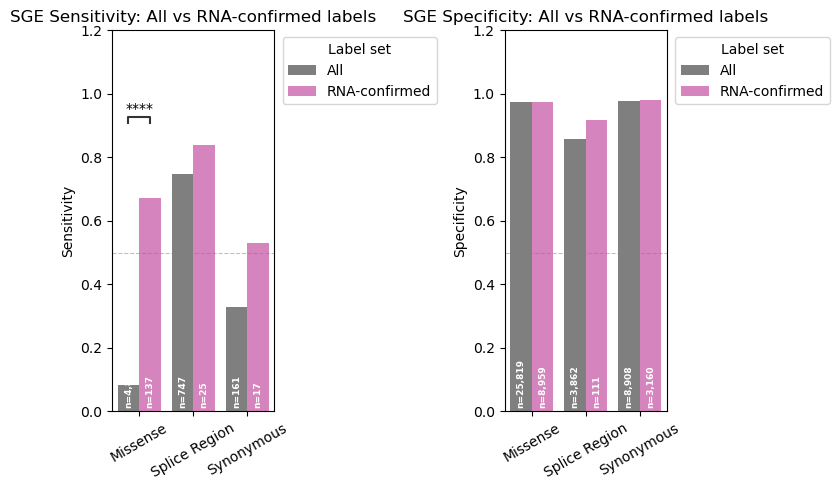

In [7]:
CONDITION_COLORS = {'All': '#7F7F7F', 'RNA-confirmed': '#E377C2'}
CONDITION_ORDER  = ['All', 'RNA-confirmed']
P_COL_RNA        = 'p_All_vs_RNA-confirmed'


def plot_rna_comparison(sens_df, spec_df):
    fig, axes = plt.subplots(1, 2, figsize=(max(8, len(sens_df) * 2.5), 5), sharey=False)

    for ax, metric_df, metric_name in zip(axes, [sens_df, spec_df], ['Sensitivity', 'Specificity']):
        cons_order = metric_df['consequence'].tolist()

        long_rows = []
        for _, row in metric_df.iterrows():
            for cond in CONDITION_ORDER:
                if not pd.isna(row[cond]):
                    long_rows.append({
                        'consequence': row['consequence'],
                        'condition':   cond,
                        'value':       row[cond],
                        'n':           int(row[f'n_{cond}']),
                    })
        long_df = pd.DataFrame(long_rows)

        sns.barplot(
            data=long_df, x='consequence', y='value', hue='condition',
            palette=CONDITION_COLORS, hue_order=CONDITION_ORDER,
            order=cons_order, ax=ax,
        )

        # n labels on bars
        n_hue     = len(CONDITION_ORDER)
        bar_width = 0.8 / n_hue
        for i, cons in enumerate(cons_order):
            for j, cond in enumerate(CONDITION_ORDER):
                subset = long_df[(long_df['consequence'] == cons) & (long_df['condition'] == cond)]
                if subset.empty:
                    continue
                x_pos = i + (j - (n_hue - 1) / 2) * bar_width
                ax.text(x_pos, 0.01, f'n={subset["n"].iloc[0]:,}',
                        ha='center', va='bottom', fontsize=6.5,
                        color='white', fontweight='bold', rotation=90)

        # Significant pairs
        sig_pairs, sig_pvals = [], []
        for _, row in metric_df.iterrows():
            p = row.get(P_COL_RNA, np.nan)
            if not pd.isna(p) and p < 0.05:
                sig_pairs.append(((row['consequence'], 'All'), (row['consequence'], 'RNA-confirmed')))
                sig_pvals.append(p)

        if sig_pairs:
            annotator = Annotator(
                ax, sig_pairs, data=long_df,
                x='consequence', y='value', hue='condition',
                order=cons_order, hue_order=CONDITION_ORDER,
            )
            annotator.configure(test=None, text_format='star', loc='outside', verbose=False)
            annotator.set_pvalues_and_annotate(sig_pvals)

        ax.set_title(f'SGE {metric_name}: All vs RNA-confirmed labels')
        ax.set_xlabel('')
        ax.set_ylabel(metric_name)
        ax.set_ylim(0, 1.2)
        ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.tick_params(axis='x', rotation=30)
        ax.legend(title='Label set', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    return fig


fig_rna = plot_rna_comparison(rna_sens_df, rna_spec_df)
plt.show()

# SpliceAI performance on different variant types

In [11]:
# Combined sensitivity/specificity per consequence: pool eligible datasets
# Drop Canonical Splice; use Low RNA labels for RNA-filterable consequences
# to avoid chi-square independence violation (plain and Low RNA rows share
# identical Curated/ClinVar CMs — picking one representative per consequence)

COMBINED_GROUPS = [
    ('Intron',                  'Intron',        False),
    ('Splice Region (Low RNA)', 'Splice Region', True),
    ('Missense (Low RNA)',      'Missense',       True),
    ('Synonymous (Low RNA)',    'Synonymous',     True),
]

# Build pooled CM per group by summing across eligible datasets
combined_cms = {}
for label, group_name, rna_filtered in COMBINED_GROUPS:
    sge_sub = get_sge_sub(sge_set, group_name, rna_filtered)
    cur_sub = curated_set[curated_set['simplified_consequence'].isin(CONSEQUENCE_MAP[group_name])]
    clv_sub = clinvar_set[clinvar_set[CLINVAR_CONS_COL].isin(CONSEQUENCE_MAP[group_name])]

    dataset_specs = [
        (sge_sub, SGE_LABEL_COL,     SGE_POS_LABEL,     SGE_NEG_LABEL),
        (cur_sub, CURATED_LABEL_COL, CURATED_POS_LABEL, CURATED_NEG_LABEL),
        (clv_sub, CLINVAR_LABEL_COL, CLINVAR_POS_LABEL, CLINVAR_NEG_LABEL),
    ]

    cm_pooled = np.zeros((2, 2), dtype=int)
    for sub_df, label_col, pos_label, neg_label in dataset_specs:
        n_pos = sub_df[label_col].eq(pos_label).sum()
        n_neg = sub_df[label_col].eq(neg_label).sum()
        if min(n_pos, n_neg) >= 5:
            cm_pooled += build_confusion_matrix(sub_df, label_col, pos_label, neg_label)

    tn, fp, fn, tp = cm_pooled[0,0], cm_pooled[0,1], cm_pooled[1,0], cm_pooled[1,1]
    if min(tp + fn, tn + fp) < 5:
        print(f'Skipping {label}: combined +{tp+fn}/-{tn+fp}')
        combined_cms[label] = None
    else:
        combined_cms[label] = cm_pooled

eligible_groups = [k for k, v in combined_cms.items() if v is not None]
cms_list        = [combined_cms[k] for k in eligible_groups]

# Summary table (keep raw TP/TN for CI calculation)
summary_rows = []
for label, cm in zip(eligible_groups, cms_list):
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    summary_rows.append({
        'consequence': label,
        'sensitivity': tp / (tp + fn),
        'specificity': tn / (tn + fp),
        'tp': int(tp), 'n_pos': int(tp + fn),
        'tn': int(tn), 'n_neg': int(tn + fp),
    })
summary_df = pd.DataFrame(summary_rows)

# --- Global chi-square test of homogeneity ---
# Bonferroni for 2 simultaneous global tests (sensitivity + specificity)
table_sens = np.array([[cm[1,1] for cm in cms_list],
                        [cm[1,0] for cm in cms_list]])
table_spec = np.array([[cm[0,0] for cm in cms_list],
                        [cm[0,1] for cm in cms_list]])

chi2_s, p_glob_sens, _, _ = chi2_contingency(table_sens)
chi2_p, p_glob_spec, _, _ = chi2_contingency(table_spec)
p_glob_sens_adj = min(p_glob_sens * 2, 1.0)
p_glob_spec_adj = min(p_glob_spec * 2, 1.0)

print('=== Global homogeneity test ===')
print(f'  Sensitivity: χ²={chi2_s:.2f}, p={p_glob_sens_adj:.4f}{"  *" if p_glob_sens_adj < 0.05 else "  ns"}')
print(f'  Specificity: χ²={chi2_p:.2f}, p={p_glob_spec_adj:.4f}{"  *" if p_glob_spec_adj < 0.05 else "  ns"}')

# --- One-vs-rest post-hoc (only interpreted if global test significant) ---
# Bonferroni: N_groups tests per metric (sensitivity and specificity corrected independently)
n_posthoc = len(eligible_groups)

posthoc_rows = []
for label in eligible_groups:
    cm_i = combined_cms[label]
    cm_rest = np.zeros((2, 2), dtype=int)
    for k in eligible_groups:
        if k != label:
            cm_rest += combined_cms[k]

    tp_i,  fn_i  = int(cm_i[1,1]),    int(cm_i[1,0])
    tp_r,  fn_r  = int(cm_rest[1,1]), int(cm_rest[1,0])
    tn_i,  fp_i  = int(cm_i[0,0]),    int(cm_i[0,1])
    tn_r,  fp_r  = int(cm_rest[0,0]), int(cm_rest[0,1])

    _, p_sens = proportions_ztest([tp_i, tp_r], [tp_i+fn_i, tp_r+fn_r])
    _, p_spec = proportions_ztest([tn_i, tn_r], [tn_i+fp_i, tn_r+fp_r])

    posthoc_rows.append({
        'consequence':   label,
        'p_sensitivity': min(p_sens * n_posthoc, 1.0),
        'p_specificity': min(p_spec * n_posthoc, 1.0),
    })

posthoc_df = pd.DataFrame(posthoc_rows)

print(f'\n=== One-vs-rest post-hoc (Bonferroni factor={n_posthoc} per metric) ===')
print(posthoc_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

=== Global homogeneity test ===
  Sensitivity: χ²=286.55, p=0.0000  *
  Specificity: χ²=473.91, p=0.0000  *

=== One-vs-rest post-hoc (Bonferroni factor=4 per metric) ===
            consequence  p_sensitivity  p_specificity
                 Intron         0.0000         0.0000
Splice Region (Low RNA)         0.0000         0.0000
     Missense (Low RNA)         1.0000         0.0000
   Synonymous (Low RNA)         0.0093         1.0000


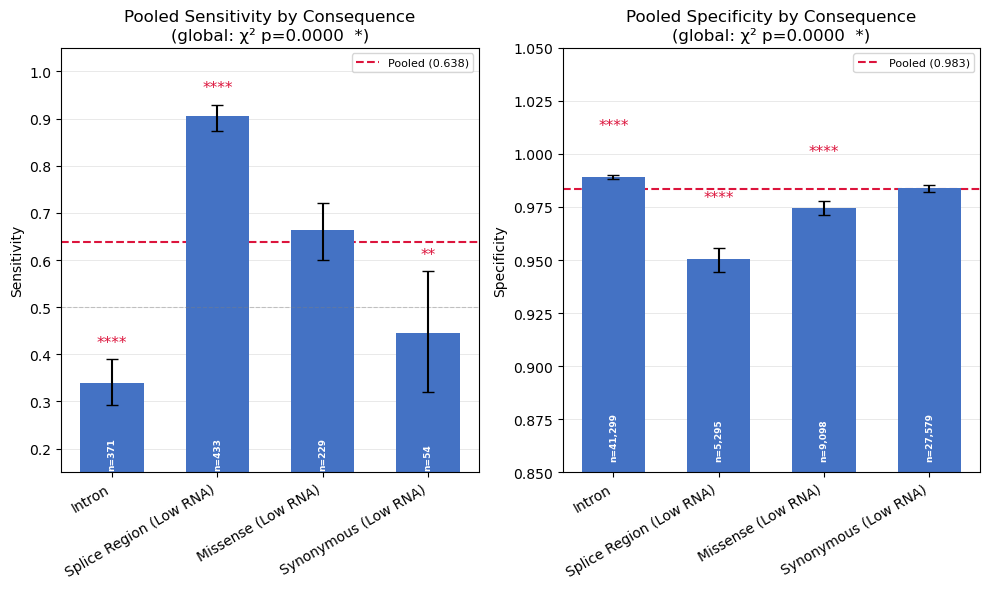

In [12]:
def star_label(p):
    if p < 0.0001: return '****'
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    return '*'


def plot_combined_comparison(summary_df, posthoc_df, p_glob_sens, p_glob_spec,
                              title_prefix='Pooled'):
    cons_order = summary_df['consequence'].tolist()
    merged     = summary_df.merge(posthoc_df, on='consequence')

    # Overall pooled proportions across all groups
    pooled_sens = summary_df['tp'].sum() / summary_df['n_pos'].sum()
    pooled_spec = summary_df['tn'].sum() / summary_df['n_neg'].sum()

    fig, axes = plt.subplots(1, 2, figsize=(max(10, len(cons_order) * 1.8), 6))

    specs = [
        ('sensitivity', 'p_sensitivity', 'tp', 'n_pos', p_glob_sens, pooled_sens),
        ('specificity', 'p_specificity', 'tn', 'n_neg', p_glob_spec, pooled_spec),
    ]

    for ax, (metric, p_col, k_col, n_col, p_global, pooled) in zip(axes, specs):
        x = np.arange(len(cons_order))

        # Wilson 95% CIs from exact counts
        lo_errs, hi_errs = [], []
        for _, row in merged.iterrows():
            lo, hi = proportion_confint(int(row[k_col]), int(row[n_col]),
                                        alpha=0.05, method='wilson')
            lo_errs.append(row[metric] - lo)
            hi_errs.append(hi - row[metric])

        ax.bar(x, merged[metric], color='#4472C4', width=0.6, zorder=2)
        ax.errorbar(x, merged[metric], yerr=[lo_errs, hi_errs],
                    fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

        # Overall pooled reference line
        ax.axhline(pooled, color='crimson', linestyle='--', linewidth=1.5,
                   zorder=1, label=f'Pooled ({pooled:.3f})')
        ax.legend(fontsize=8, loc='upper right')

        # n labels inside bars — anchor to y_min so they stay visible
        y_min = max(0, np.floor((min(merged[metric]) - max(lo_errs) - 0.05) * 20) / 20)
        for i, (_, row) in enumerate(merged.iterrows()):
            ax.text(i, y_min + 0.005, f'n={int(row[n_col]):,}',
                    ha='center', va='bottom', fontsize=6.5,
                    color='white', fontweight='bold', rotation=90)

        # Asterisks above bars for significant one-vs-rest
        if p_global < 0.05:
            for i, (_, row) in enumerate(merged.iterrows()):
                p = row[p_col]
                if p < 0.05:
                    bar_top = row[metric] + hi_errs[i]
                    ax.text(i, bar_top + 0.02, star_label(p),
                            ha='center', va='bottom', fontsize=11, color='crimson')

        global_str = f'χ² p={p_global:.4f}' + ('  *' if p_global < 0.05 else '  ns')
        ax.set_title(f'{title_prefix} {metric.capitalize()} by Consequence\n(global: {global_str})')
        ax.set_xlabel('')
        ax.set_ylabel(metric.capitalize())
        ax.set_ylim(y_min, 1.05)
        ax.set_xticks(x)
        ax.set_xticklabels(cons_order, rotation=30, ha='right')
        ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.4)
        ax.grid(axis='y', linewidth=0.5, alpha=0.4, zorder=0)

    plt.tight_layout()
    return fig


fig_combined = plot_combined_comparison(
    summary_df, posthoc_df, p_glob_sens_adj, p_glob_spec_adj
)
plt.show()


=== SGE (groups=4) ===
  Sensitivity: χ²=66.88, p=0.0000  *
  Specificity: χ²=35.14, p=0.0000  *
            consequence  p_sensitivity  p_specificity
                 Intron         0.0000         0.0001
Splice Region (Low RNA)         0.0002         0.0021
     Missense (Low RNA)         0.0000         0.1201
   Synonymous (Low RNA)         1.0000         0.0026
Curated / Intron: skipped (+4/-3)

=== Curated (groups=3) ===
  Sensitivity: χ²=13.94, p=0.0019  *
  Specificity: χ²=14.73, p=0.0013  *
  consequence  p_sensitivity  p_specificity
Splice Region         0.0012         0.0199
     Missense         0.0511         0.0004
   Synonymous         0.1343         0.0952
ClinVar / Missense: skipped (+2/-1)

=== ClinVar (groups=3) ===
  Sensitivity: χ²=76.59, p=0.0000  *
  Specificity: χ²=627.88, p=0.0000  *
  consequence  p_sensitivity  p_specificity
       Intron         0.0000         0.0000
Splice Region         0.0000         0.0000
   Synonymous         0.0000         0.0000


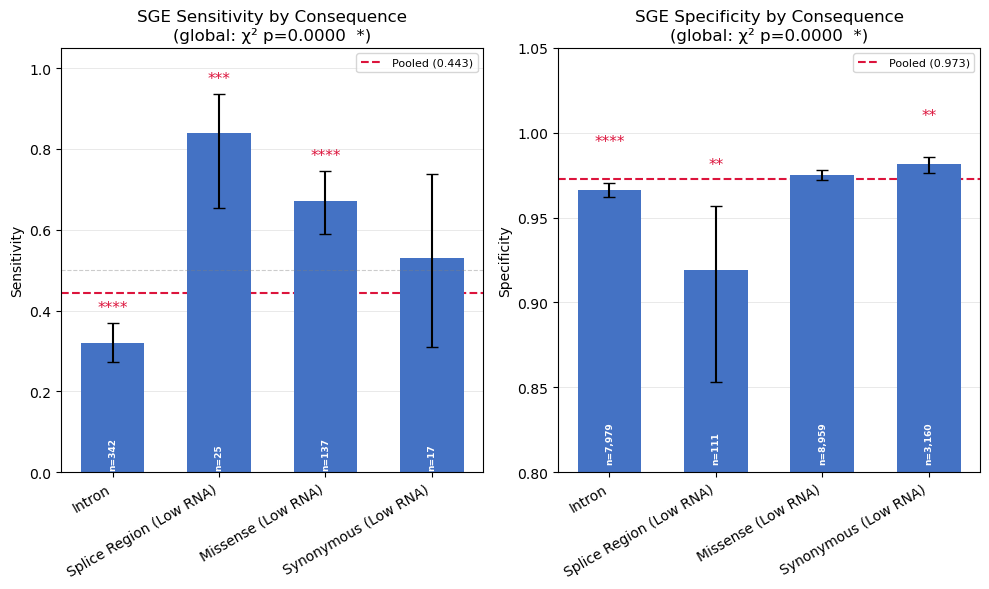

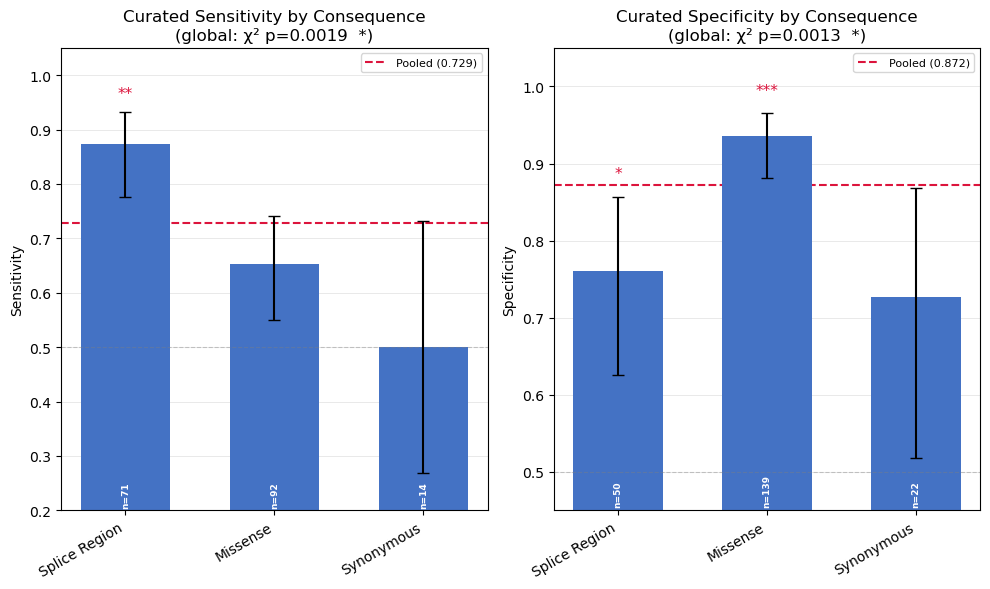

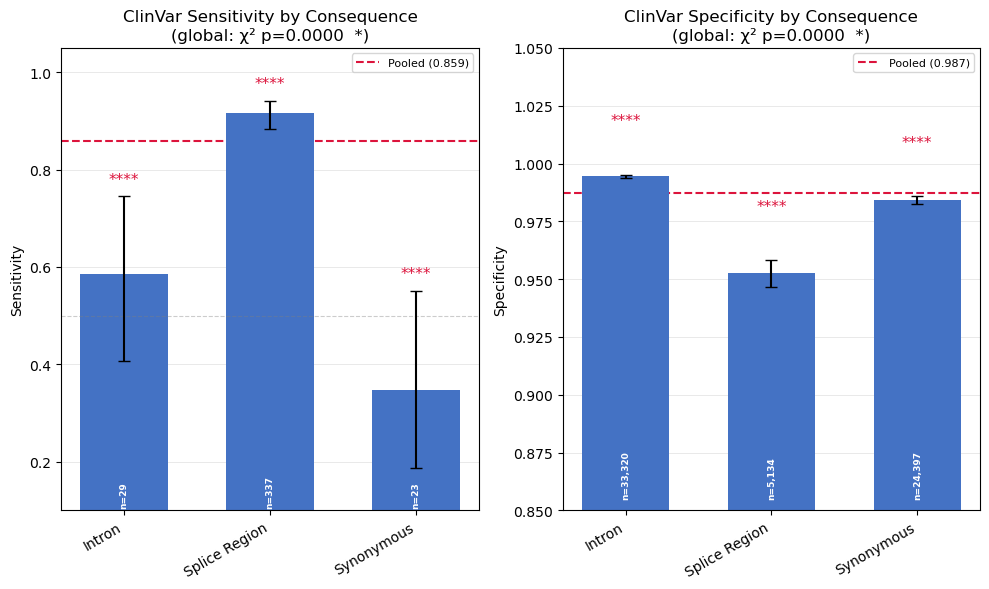

In [13]:
# Per-dataset sensitivity/specificity by variant consequence
# SGE: Low RNA filtering for RNA-filterable consequences (consistent with pooled analysis)
# Curated / ClinVar: no RNA filtering available — all variants used
# Consequences with insufficient counts (<5 pos or neg) are excluded per dataset

PER_DATASET_GROUPS = {
    'SGE': [
        ('Intron',                  'Intron',        False),
        ('Splice Region (Low RNA)', 'Splice Region', True),
        ('Missense (Low RNA)',      'Missense',       True),
        ('Synonymous (Low RNA)',    'Synonymous',     True),
    ],
    'Curated': [
        ('Intron',        'Intron',        False),
        ('Splice Region', 'Splice Region', False),
        ('Missense',      'Missense',       False),
        ('Synonymous',    'Synonymous',     False),
    ],
    'ClinVar': [
        ('Intron',        'Intron',        False),
        ('Splice Region', 'Splice Region', False),
        ('Missense',      'Missense',       False),
        ('Synonymous',    'Synonymous',     False),
    ],
}

DATASET_SPECS = {
    'SGE':     (None,        SGE_LABEL_COL,     SGE_POS_LABEL,     SGE_NEG_LABEL,     None),
    'Curated': (curated_set, CURATED_LABEL_COL, CURATED_POS_LABEL, CURATED_NEG_LABEL, 'simplified_consequence'),
    'ClinVar': (clinvar_set, CLINVAR_LABEL_COL, CLINVAR_POS_LABEL, CLINVAR_NEG_LABEL, CLINVAR_CONS_COL),
}

figs_per_dataset = {}

for ds_name, groups in PER_DATASET_GROUPS.items():
    df_full, label_col, pos_label, neg_label, cons_col = DATASET_SPECS[ds_name]

    cms_map = {}
    for display_label, consequence_key, rna_filtered in groups:
        if ds_name == 'SGE':
            sub = get_sge_sub(sge_set, consequence_key, rna_filtered)
        else:
            sub = df_full[df_full[cons_col].isin(CONSEQUENCE_MAP[consequence_key])]

        n_pos = sub[label_col].eq(pos_label).sum()
        n_neg = sub[label_col].eq(neg_label).sum()
        if min(n_pos, n_neg) >= 5:
            cms_map[display_label] = build_confusion_matrix(sub, label_col, pos_label, neg_label)
        else:
            print(f'{ds_name} / {display_label}: skipped (+{n_pos}/-{n_neg})')
            cms_map[display_label] = None

    eligible = [k for k, v in cms_map.items() if v is not None]
    if len(eligible) < 2:
        print(f'Skipping {ds_name}: fewer than 2 eligible groups')
        continue

    cms_list = [cms_map[k] for k in eligible]

    # Summary table
    summary_rows_ds = []
    for label, cm in zip(eligible, cms_list):
        tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
        summary_rows_ds.append({
            'consequence': label,
            'sensitivity': tp / (tp + fn),
            'specificity': tn / (tn + fp),
            'tp': int(tp), 'n_pos': int(tp + fn),
            'tn': int(tn), 'n_neg': int(tn + fp),
        })
    summary_df_ds = pd.DataFrame(summary_rows_ds)

    # Global chi-square (Bonferroni × 2 for two simultaneous global tests)
    table_sens = np.array([[cm[1,1] for cm in cms_list], [cm[1,0] for cm in cms_list]])
    table_spec = np.array([[cm[0,0] for cm in cms_list], [cm[0,1] for cm in cms_list]])

    chi2_s, p_gs, _, _ = chi2_contingency(table_sens)
    chi2_p, p_gp, _, _ = chi2_contingency(table_spec)
    p_gs_adj = min(p_gs * 2, 1.0)
    p_gp_adj = min(p_gp * 2, 1.0)

    # One-vs-rest post-hoc (Bonferroni per metric)
    n_posthoc = len(eligible)
    posthoc_rows_ds = []
    for label in eligible:
        cm_i    = cms_map[label]
        cm_rest = np.zeros((2, 2), dtype=int)
        for k in eligible:
            if k != label:
                cm_rest += cms_map[k]

        tp_i, fn_i = int(cm_i[1,1]),    int(cm_i[1,0])
        tp_r, fn_r = int(cm_rest[1,1]), int(cm_rest[1,0])
        tn_i, fp_i = int(cm_i[0,0]),    int(cm_i[0,1])
        tn_r, fp_r = int(cm_rest[0,0]), int(cm_rest[0,1])

        _, p_sens = proportions_ztest([tp_i, tp_r], [tp_i+fn_i, tp_r+fn_r])
        _, p_spec = proportions_ztest([tn_i, tn_r], [tn_i+fp_i, tn_r+fp_r])

        posthoc_rows_ds.append({
            'consequence':   label,
            'p_sensitivity': min(p_sens * n_posthoc, 1.0),
            'p_specificity': min(p_spec * n_posthoc, 1.0),
        })
    posthoc_df_ds = pd.DataFrame(posthoc_rows_ds)

    print(f'\n=== {ds_name} (groups={n_posthoc}) ===')
    print(f'  Sensitivity: χ²={chi2_s:.2f}, p={p_gs_adj:.4f}{"  *" if p_gs_adj < 0.05 else "  ns"}')
    print(f'  Specificity: χ²={chi2_p:.2f}, p={p_gp_adj:.4f}{"  *" if p_gp_adj < 0.05 else "  ns"}')
    print(posthoc_df_ds.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    fig = plot_combined_comparison(
        summary_df_ds, posthoc_df_ds, p_gs_adj, p_gp_adj,
        title_prefix=ds_name,
    )
    figs_per_dataset[ds_name] = fig

plt.show()

# Analysis of intronic variants with and without SGE

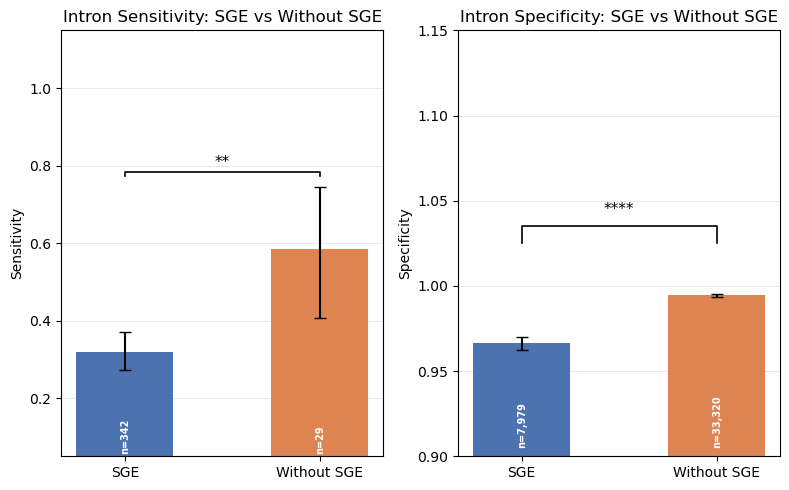

In [10]:
# Intron variants: SGE vs without SGE (Curated + ClinVar pooled)

intron_cons = CONSEQUENCE_MAP['Intron']

sge_intron = get_sge_sub(sge_set, 'Intron', rna_filtered=False)
cur_intron  = curated_set[curated_set['simplified_consequence'].isin(intron_cons)]
clv_intron  = clinvar_set[clinvar_set[CLINVAR_CONS_COL].isin(intron_cons)]

cm_sge = build_confusion_matrix(sge_intron, SGE_LABEL_COL,     SGE_POS_LABEL,     SGE_NEG_LABEL)

cm_no_sge = np.zeros((2, 2), dtype=int)
for sub_df, label_col, pos_label, neg_label in [
    (cur_intron, CURATED_LABEL_COL, CURATED_POS_LABEL, CURATED_NEG_LABEL),
    (clv_intron, CLINVAR_LABEL_COL, CLINVAR_POS_LABEL, CLINVAR_NEG_LABEL),
]:
    n_pos = sub_df[label_col].eq(pos_label).sum()
    n_neg = sub_df[label_col].eq(neg_label).sum()
    if min(n_pos, n_neg) >= 5:
        cm_no_sge += build_confusion_matrix(sub_df, label_col, pos_label, neg_label)

result = compare_components([cm_sge, cm_no_sge], ['SGE', 'Without SGE'])

# Build plot DataFrame
intron_rows = []
for label, cm in [('SGE', cm_sge), ('Without SGE', cm_no_sge)]:
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    intron_rows.append({
        'group':       label,
        'sensitivity': tp / (tp + fn),
        'specificity': tn / (tn + fp),
        'tp': int(tp), 'n_pos': int(tp + fn),
        'tn': int(tn), 'n_neg': int(tn + fp),
    })
intron_df = pd.DataFrame(intron_rows)

GROUP_COLORS = {'SGE': '#4C72B0', 'Without SGE': '#DD8452'}
GROUP_ORDER  = ['SGE', 'Without SGE']

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

specs = [
    ('sensitivity', 'sensitivity', 'tp', 'n_pos', 'p_SGE_vs_Without SGE'),
    ('specificity', 'specificity', 'tn', 'n_neg', 'p_SGE_vs_Without SGE'),
]

for ax, (metric, val_col, k_col, n_col, p_key) in zip(axes, specs):
    p = result[metric][p_key]

    lo_errs, hi_errs = [], []
    for _, row in intron_df.iterrows():
        lo, hi = proportion_confint(int(row[k_col]), int(row[n_col]),
                                    alpha=0.05, method='wilson')
        lo_errs.append(row[val_col] - lo)
        hi_errs.append(hi - row[val_col])

    x = np.arange(len(GROUP_ORDER))
    bars = [intron_df.loc[intron_df['group'] == g, val_col].iloc[0] for g in GROUP_ORDER]
    colors = [GROUP_COLORS[g] for g in GROUP_ORDER]

    ax.bar(x, bars, color=colors, width=0.5, zorder=2)
    ax.errorbar(x, bars, yerr=[lo_errs, hi_errs],
                fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

    # n labels
    y_min = max(0, np.floor((min(bars) - max(lo_errs) - 0.05) * 20) / 20)
    for i, (g, n) in enumerate(zip(GROUP_ORDER,
                                    [intron_df.loc[intron_df['group']==g, n_col].iloc[0]
                                     for g in GROUP_ORDER])):
        ax.text(i, y_min + 0.005, f'n={int(n):,}',
                ha='center', va='bottom', fontsize=7,
                color='white', fontweight='bold', rotation=90)

    # Significance bracket
    if not pd.isna(p) and p < 0.05:
        bracket_y = max(b + e for b, e in zip(bars, hi_errs)) + 0.03
        ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + 0.01, bracket_y + 0.01, bracket_y],
                color='black', linewidth=1.2)
        ax.text(0.5, bracket_y + 0.015, star_label(p),
                ha='center', va='bottom', fontsize=11)

    ax.set_title(f'Intron {metric.capitalize()}: SGE vs Without SGE')
    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER)
    ax.set_xlabel('')
    ax.set_ylabel(metric.capitalize())
    ax.set_ylim(y_min, 1.15)
    ax.grid(axis='y', linewidth=0.5, alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()